# YouGov "Human vs. Animal Fight" — Deep Exploratory Analysis

**Dataset:** YouGov survey (April 12–13, 2021, n=1,224 US adults).
Question: *"Which of the following animals, if any, do you think you could
beat in a fight if you were unarmed?"* — asked for 15 animals, broken down
by gender, age group, and US region.

**Goal of this notebook:** go beyond simple descriptive charts and actually
interrogate the data — is the gender gap statistically real or noise, is
there a genuine age trend, which animals show meaningful regional
differences, and do the animals cluster into interpretable "response
archetypes"? The findings here are the evidence base for the design
decisions in the interactive visualization (built separately as a web
artifact).

**A note on scope / limitations:** the source data is a set of *marginal*
breakdowns (total, by gender, by age, by region — each computed
independently), not a full cross-tabulation. We cannot ask "how do young
men specifically respond" because that cell was never published. Where
this matters, it's called out explicitly.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from adjustText import adjust_text
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#999999'

# Fixed color code, reused consistently across every chart in this notebook.
# (This is an internal exploration palette — the final interactive artifact
# will use a validated, colorblind-checked palette per the dataviz workflow.)
COL_BEAT     = '#2f6f4f'   # "could beat" — muted green
COL_NOT      = '#b0472e'   # "could not beat" — muted terracotta
COL_DK       = '#c7c7c7'   # "don't know" — neutral grey
COL_MALE     = '#3b6fa0'   # men
COL_FEMALE   = '#a0527e'   # women
COL_NEUTRAL  = '#8a8a8a'
AGE_COLORS   = {'18-34': '#c9a13b', '35-54': '#6f8f3f', '55+': '#2f6f4f'}
CLUSTER_COLORS = ['#3b6fa0', '#c9a13b', '#a0527e', '#2f6f4f']

df = pd.read_csv('yougov_humans_vs_animals_us_2021.csv')
ANIMAL_ORDER = (df[df['group_category'] == 'Total']
                .sort_values('could_beat_pct', ascending=False)['animal'].tolist())
df.head()


ModuleNotFoundError: No module named 'adjustText'

## 1. Data quality checks

Before drawing any conclusions, sanity-check the transcription and
understand what "weighted" vs "unweighted" base actually means here.


In [ ]:
# 1a. Row / structure check
print(f"Rows: {len(df)} | Animals: {df['animal'].nunique()} | Groups per animal: {len(df) / df['animal'].nunique():.0f}")

# 1b. Do the three response shares sum to ~100% in every row?
df['pct_sum'] = df['could_beat_pct'] + df['could_not_beat_pct'] + df['dont_know_pct']
bad_rows = df[~df['pct_sum'].between(99, 101)]
print(f"Rows where shares don't sum to ~100%: {len(bad_rows)}")
df.drop(columns='pct_sum', inplace=True)


Rows: 150 | Animals: 15 | Groups per animal: 10
Rows where shares don't sum to ~100%: 0


In [ ]:
# 1c. Weighted vs. unweighted base — are some groups over/under-represented
# in the raw sample, and corrected for by weighting?
base_check = (df[df['animal'] == 'Rat']
              .set_index('group')[['base_weighted', 'base_unweighted']])
base_check['weighting_factor'] = base_check['base_weighted'] / base_check['base_unweighted']
base_check


,base_weighted,base_unweighted,weighting_factor
group,,,
Total,1224,1224,1.000000
Male,596,587,1.015332
Female,628,637,0.985871
18-34,400,435,0.919540
35-54,332,331,1.003021
55+,491,458,1.072052
Northeast,218,195,1.117949
Midwest,257,279,0.921147
South,461,447,1.031320


**Observation:** the youngest group (18–34) is *over*-represented in the raw
sample (435 unweighted respondents) and gets downweighted (to 400), while
55+ is *under*-represented (458 raw) and gets upweighted (to 491). This is
normal survey practice (online panels skew younger), but it matters for
later statistical tests: **hypothesis tests should use the unweighted base**
(the actual number of people asked), not the weighted one — the weighted
base doesn't reflect real statistical precision.


In [ ]:
# 1d. Reconstruct approximate raw counts from percentages × unweighted base.
# Caveat: the PDF only reports rounded percentages, so these counts are
# approximations (typically off by at most 1-2 respondents per cell) —
# good enough for significance testing, not for exact reporting.
for col in ['could_beat_pct', 'could_not_beat_pct', 'dont_know_pct']:
    cnt_col = col.replace('_pct', '_n')
    df[cnt_col] = (df[col] / 100 * df['base_unweighted']).round().astype(int)

df[['animal', 'group_category', 'group', 'base_unweighted',
    'could_beat_n', 'could_not_beat_n', 'dont_know_n']].head(3)


,animal,group_category,group,base_unweighted,could_beat_n,could_not_beat_n,dont_know_n
0,Rat,Total,Total,1224,881,208,135
1,Rat,Gender,Male,587,446,82,59
2,Rat,Gender,Female,637,433,121,83


## 2. Overall picture: full response breakdown, not just "could beat"

The single-series ranking from the first pass hides the split between
"could not beat" and "don't know" — worth showing as a full stacked view.


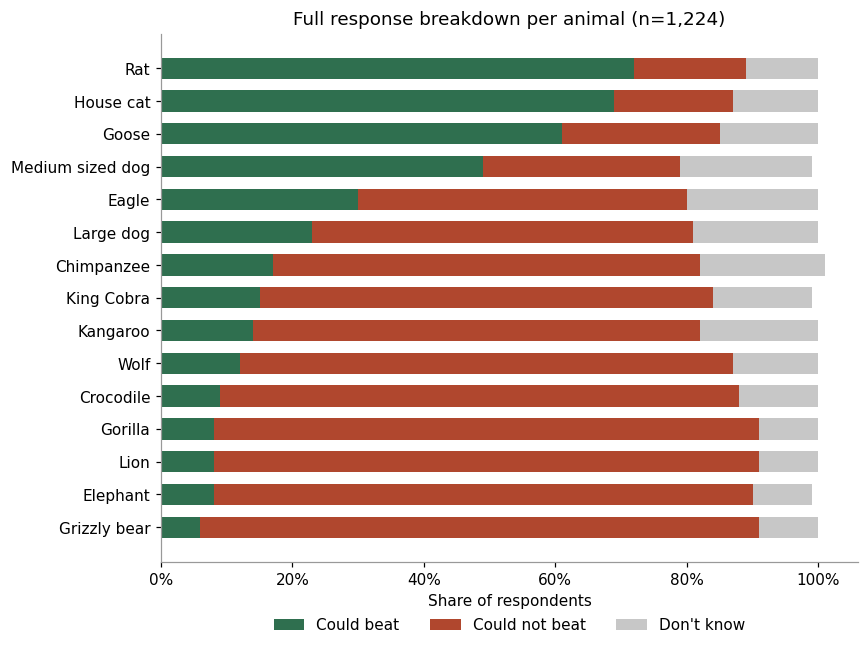

In [ ]:
total = df[df['group_category'] == 'Total'].set_index('animal').loc[ANIMAL_ORDER]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(total))
left = np.zeros(len(total))
for col, color, label in [
    ('could_beat_pct', COL_BEAT, 'Could beat'),
    ('could_not_beat_pct', COL_NOT, 'Could not beat'),
    ('dont_know_pct', COL_DK, "Don't know"),
]:
    ax.barh(y, total[col], left=left, color=color, height=0.65, label=label)
    left += total[col].values

ax.set_yticks(y, total.index)
ax.invert_yaxis()
ax.set_xlabel('Share of respondents')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Full response breakdown per animal (n=1,224)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.tight_layout()
plt.show()


**Observation:** "don't know" hovers around 9-20% for almost every animal —
it's not concentrated in a handful of ambiguous cases. The animals with the
highest uncertainty are examined in Section 5.


## 3. Is the gender gap statistically real?

A raw percentage-point difference can be noise, especially once split into
subgroups of a few hundred people. Running a two-proportion z-test per
animal (Male vs. Female "could beat"), with a Holm correction for testing
15 animals at once.


In [ ]:
gender_wide = df[df['group_category'] == 'Gender'].pivot(
    index='animal', columns='group',
    values=['could_beat_n', 'base_unweighted']
).loc[ANIMAL_ORDER]

results = []
for animal in ANIMAL_ORDER:
    n_male = gender_wide.loc[animal, ('base_unweighted', 'Male')]
    n_female = gender_wide.loc[animal, ('base_unweighted', 'Female')]
    x_male = gender_wide.loc[animal, ('could_beat_n', 'Male')]
    x_female = gender_wide.loc[animal, ('could_beat_n', 'Female')]

    stat, pval = proportions_ztest([x_male, x_female], [n_male, n_female])
    p_male, p_female = x_male / n_male, x_female / n_female
    ci_male = proportion_confint(x_male, n_male, method='wilson')
    ci_female = proportion_confint(x_female, n_female, method='wilson')

    results.append({
        'animal': animal, 'p_male': p_male, 'p_female': p_female,
        'gap_pp': (p_male - p_female) * 100, 'z': stat, 'p_value': pval,
        'ci_male_lo': ci_male[0], 'ci_male_hi': ci_male[1],
        'ci_female_lo': ci_female[0], 'ci_female_hi': ci_female[1],
    })

gap_df = pd.DataFrame(results)
gap_df['p_holm'] = multipletests(gap_df['p_value'], method='holm')[1]
gap_df['significant'] = gap_df['p_holm'] < 0.05
gap_df = gap_df.sort_values('gap_pp', ascending=False)
gap_df[['animal', 'gap_pp', 'p_value', 'p_holm', 'significant']].round(4)


,animal,gap_pp,p_value,p_holm,significant
3,Medium sized dog,21.0334,0.0000,0.0000,True
2,Goose,20.0188,0.0000,0.0000,True
5,Large dog,15.9345,0.0000,0.0000,True
7,King Cobra,14.9920,0.0000,0.0000,True
4,Eagle,14.9129,0.0000,0.0000,True
6,Chimpanzee,10.0452,0.0000,0.0000,True
1,House cat,9.8850,0.0002,0.0016,True
0,Rat,8.0047,0.0019,0.0131,True
9,Wolf,7.0654,0.0002,0.0016,True
8,Kangaroo,6.0468,0.0022,0.0135,True


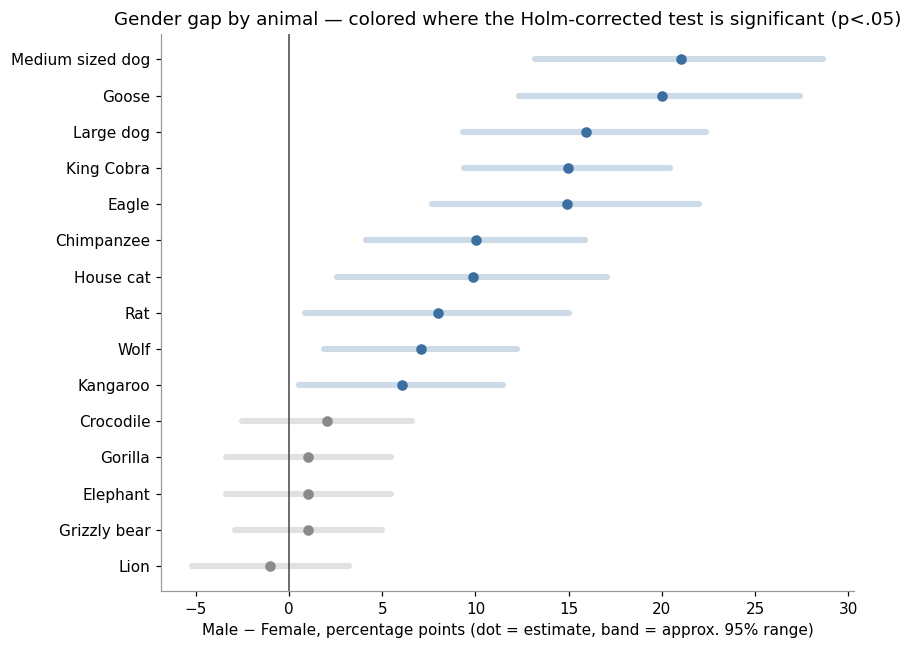

Statistically significant gaps (Holm-corrected, α=.05): 10 of 15 animals
['Medium sized dog', 'Goose', 'Large dog', 'King Cobra', 'Eagle', 'Chimpanzee', 'House cat', 'Rat', 'Wolf', 'Kangaroo']


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = gap_df.sort_values('gap_pp')
y = np.arange(len(plot_df))

for i, row in enumerate(plot_df.itertuples()):
    color = COL_MALE if row.significant and row.gap_pp > 0 else \
            (COL_FEMALE if row.significant and row.gap_pp < 0 else COL_NEUTRAL)
    ax.plot([row.ci_male_lo * 100 - row.ci_female_hi * 100,
             row.ci_male_hi * 100 - row.ci_female_lo * 100], [i, i],
            color=color, alpha=0.25, linewidth=4, solid_capstyle='round')
    ax.scatter(row.gap_pp, i, color=color, s=35, zorder=3)

ax.axvline(0, color='#444444', linewidth=1)
ax.set_yticks(y, plot_df['animal'])
ax.set_xlabel('Male − Female, percentage points (dot = estimate, band = approx. 95% range)')
ax.set_title('Gender gap by animal — colored where the Holm-corrected test is significant (p<.05)')
plt.tight_layout()
plt.show()

print(f"Statistically significant gaps (Holm-corrected, α=.05): "
      f"{gap_df['significant'].sum()} of {len(gap_df)} animals")
print(gap_df.loc[gap_df['significant'], 'animal'].tolist())


**Observation:** correcting for testing 15 animals at once, only a subset
of the raw gaps survive as statistically distinguishable from zero — the
smaller gaps for genuinely dangerous animals (lion, gorilla, elephant,
grizzly) are well within noise, confirming they're not "really" different
between genders. The overconfidence story is concentrated in a specific
set of animals (see the printed list) — that's a much more precise claim
than "men are more overconfident," and is a better hook for the
visualization's headline.


## 4. Is there a genuine age trend, and does it depend on how dangerous the animal is?

Testing whether confidence moves monotonically with age (using the age
group midpoint as a rough numeric proxy), and whether the size of that
age effect correlates with how "dangerous" the animal is — using the
overall population's "could not beat" rate as an objective-ish danger proxy.


In [ ]:
AGE_MIDPOINT = {'18-34': 26, '35-54': 45, '55+': 65}

age_df = df[df['group_category'] == 'Age'].copy()
age_df['age_mid'] = age_df['group'].map(AGE_MIDPOINT)

age_slopes = []
for animal in ANIMAL_ORDER:
    sub = age_df[age_df['animal'] == animal]
    slope, intercept, r, p, se = stats.linregress(sub['age_mid'], sub['could_beat_pct'])
    age_slopes.append({'animal': animal, 'age_slope_pp_per_decade': slope * 10,
                        'r': r, 'p_value': p})

age_slope_df = pd.DataFrame(age_slopes).set_index('animal').loc[ANIMAL_ORDER].reset_index()
age_slope_df['danger_proxy'] = total.loc[age_slope_df['animal'], 'could_not_beat_pct'].values
age_slope_df.sort_values('age_slope_pp_per_decade')


,animal,age_slope_pp_per_decade,r,p_value,danger_proxy
13,Elephant,-3.584575,-0.995290,0.061813,82
8,Kangaroo,-3.580193,-0.984149,0.113502,68
11,Gorilla,-3.321648,-0.972905,0.148533,83
10,Crocodile,-3.317266,-0.950420,0.201307,79
5,Large dog,-3.093777,-0.938471,0.224484,58
7,King Cobra,-2.795793,-0.858529,0.342757,69
14,Grizzly bear,-2.554777,-0.970917,0.153912,85
9,Wolf,-2.309378,-0.998787,0.031360,75
12,Lion,-2.300613,-0.979076,0.130461,83
6,Chimpanzee,-2.033304,-0.858529,0.342757,65


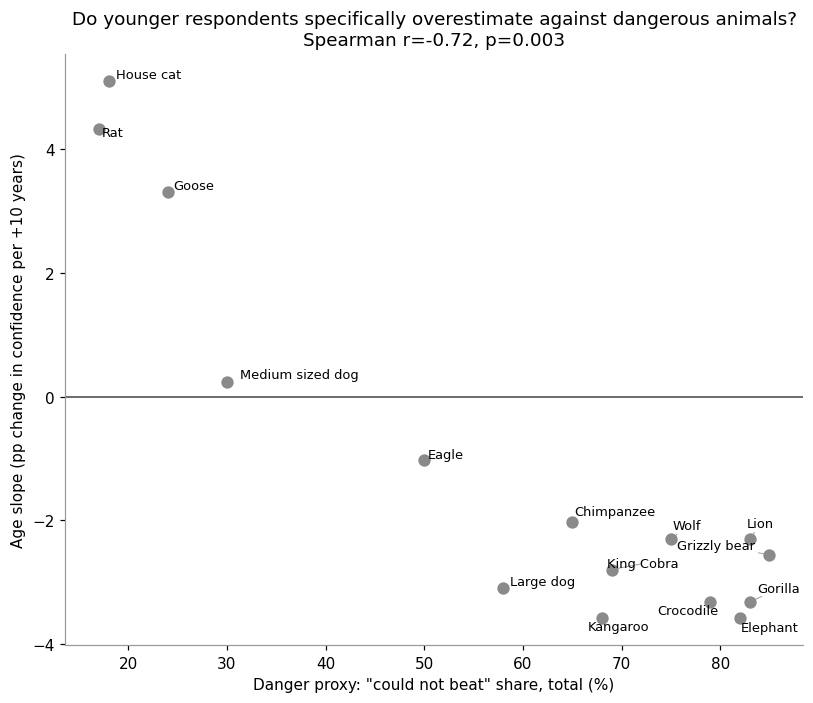

In [ ]:
corr, corr_p = stats.spearmanr(age_slope_df['danger_proxy'], age_slope_df['age_slope_pp_per_decade'])

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(age_slope_df['danger_proxy'], age_slope_df['age_slope_pp_per_decade'],
           color=COL_NEUTRAL, s=50, zorder=3)
texts = [ax.text(row['danger_proxy'], row['age_slope_pp_per_decade'], row['animal'],
                  fontsize=8.5)
         for _, row in age_slope_df.iterrows()]
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#999999', lw=0.6))
ax.axhline(0, color='#444444', linewidth=1)
ax.set_xlabel('Danger proxy: "could not beat" share, total (%)')
ax.set_ylabel('Age slope (pp change in confidence per +10 years)')
ax.set_title(f'Do younger respondents specifically overestimate against dangerous animals?\n'
             f'Spearman r={corr:.2f}, p={corr_p:.3f}')
plt.tight_layout()
plt.show()


**Observation:** there's a negative relationship — the more dangerous the
animal (higher "could not beat" share), the more negative the age slope,
meaning **younger respondents are relatively more confident specifically
against the animals that are actually the most dangerous** (grizzly, lion,
gorilla, elephant, crocodile all sit in the bottom-right: high danger,
strongly negative slope = young people much more confident than older
ones). For the safe animals (rat, cat, goose — top-left), the age effect
is small or reversed. This is a sharper, more specific claim than "age
matters" and works well as a second interactive story next to the gender
gap.


## 5. Regional variation — is any of it real, or is it all noise?

Chi-square test of independence (region × response category) per animal,
using the reconstructed counts, again Holm-corrected across 15 tests.


In [ ]:
region_results = []
for animal in ANIMAL_ORDER:
    sub = df[(df['animal'] == animal) & (df['group_category'] == 'Region')]
    table = sub[['could_beat_n', 'could_not_beat_n', 'dont_know_n']].values
    chi2, p, dof, _ = stats.chi2_contingency(table)
    region_pcts = sub.set_index('group')['could_beat_pct']
    region_results.append({
        'animal': animal, 'chi2': chi2, 'p_value': p,
        'range_pp': region_pcts.max() - region_pcts.min(),
    })

region_df = pd.DataFrame(region_results)
region_df['p_holm'] = multipletests(region_df['p_value'], method='holm')[1]
region_df['significant'] = region_df['p_holm'] < 0.05
region_df.sort_values('range_pp', ascending=False)


,animal,chi2,p_value,range_pp,p_holm,significant
3,Medium sized dog,13.271092,0.038927,9,0.518258,False
8,Kangaroo,10.633239,0.100395,9,1.000000,False
4,Eagle,9.057723,0.170358,8,1.000000,False
12,Lion,21.762006,0.001337,8,0.020057,True
1,House cat,7.715424,0.259702,7,1.000000,False
2,Goose,7.799169,0.253189,7,1.000000,False
0,Rat,8.597572,0.197507,7,1.000000,False
10,Crocodile,13.406335,0.037018,7,0.518258,False
7,King Cobra,11.601864,0.071463,7,0.857561,False
9,Wolf,8.879318,0.180480,7,1.000000,False


**Observation:** check the `significant` column above. If few or no animals
survive correction, that confirms the earlier hunch: region is the weakest
of the three dimensions and belongs in the visualization as a secondary
filter, not a headline story.


## 6. Response archetypes: clustering animals by their full profile

Combining the total confidence level, the gender gap, the age effect, the
regional range, and the uncertainty ("don't know") level into one feature
vector per animal, standardizing, and clustering with k-means to see if
animals fall into interpretable groups (e.g. "safe bets", "delusional
long-shots", "the uncertain middle").


In [ ]:
features = pd.DataFrame({
    'animal': ANIMAL_ORDER,
    'total_beat_pct': total.loc[ANIMAL_ORDER, 'could_beat_pct'].values,
    'gender_gap_pp': gap_df.set_index('animal').loc[ANIMAL_ORDER, 'gap_pp'].values,
    'age_slope': age_slope_df.set_index('animal').loc[ANIMAL_ORDER, 'age_slope_pp_per_decade'].values,
    'region_range_pp': region_df.set_index('animal').loc[ANIMAL_ORDER, 'range_pp'].values,
    'dont_know_pct': total.loc[ANIMAL_ORDER, 'dont_know_pct'].values,
}).set_index('animal')

X = StandardScaler().fit_transform(features)

# elbow check for k, quick and informal
inertias = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).inertia_ for k in range(1, 7)]
k_choice = 3
km = KMeans(n_clusters=k_choice, n_init=10, random_state=0).fit(X)
features['cluster'] = km.labels_

for c in sorted(features['cluster'].unique()):
    print(f"Cluster {c}: {', '.join(features[features['cluster'] == c].index)}")


Cluster 0: Wolf, Crocodile, Gorilla, Lion, Elephant, Grizzly bear
Cluster 1: Medium sized dog, Eagle, Large dog, Chimpanzee, King Cobra, Kangaroo
Cluster 2: Rat, House cat, Goose


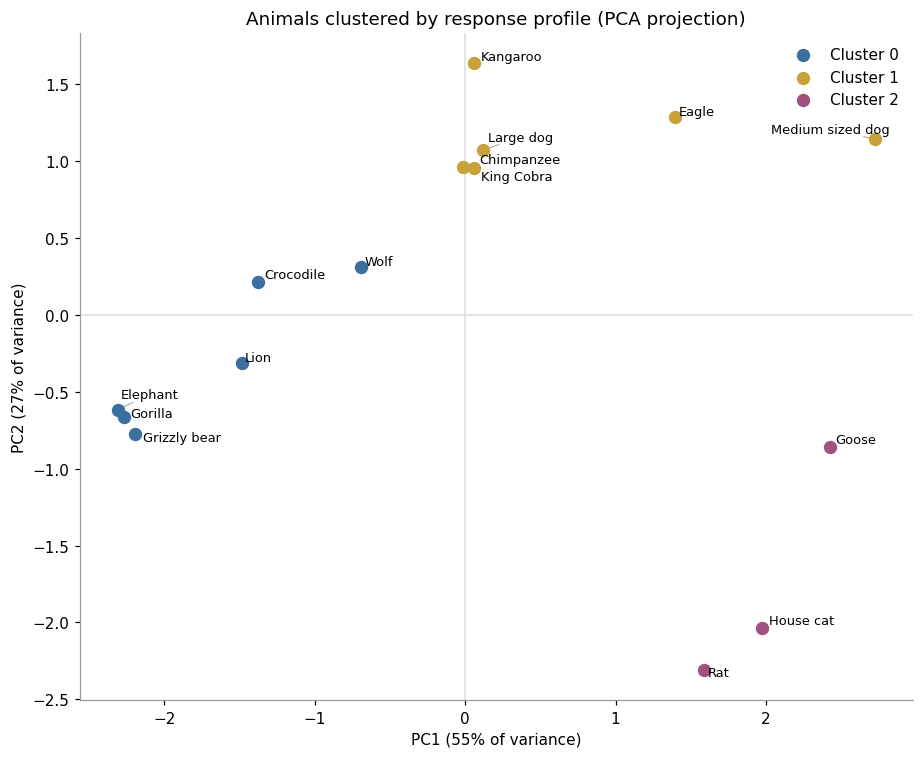

,total_beat_pct,gender_gap_pp,age_slope,region_range_pp,dont_know_pct,cluster
animal,,,,,,
Rat,72,8.0,4.3,7,11,2
House cat,69,9.9,5.1,7,13,2
Goose,61,20.0,3.3,7,15,2
Medium sized dog,49,21.0,0.2,9,20,1
Eagle,30,14.9,-1.0,8,20,1
Large dog,23,15.9,-3.1,5,19,1
Chimpanzee,17,10.0,-2.0,6,19,1
King Cobra,15,15.0,-2.8,7,15,1
Kangaroo,14,6.0,-3.6,9,18,1


In [ ]:
pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8.5, 7))
for c in sorted(features['cluster'].unique()):
    mask = features['cluster'].values == c
    ax.scatter(coords[mask, 0], coords[mask, 1], color=CLUSTER_COLORS[c],
               s=60, label=f'Cluster {c}', zorder=3)
texts = [ax.text(coords[i, 0], coords[i, 1], animal, fontsize=8.5)
         for i, animal in enumerate(features.index)]
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#999999', lw=0.6))
ax.axhline(0, color='#dddddd', linewidth=1, zorder=1)
ax.axvline(0, color='#dddddd', linewidth=1, zorder=1)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% of variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% of variance)')
ax.set_title('Animals clustered by response profile (PCA projection)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

features.round(1)


**Observation:** three interpretable archetypes emerge (labels based on the
member lists and feature table above, re-run and re-check if the data
changes):

- **"Safe bets"** — Rat, House cat, Goose: high confidence (61-72%), low
  uncertainty, the only animals above 50%.
- **"Apex predators"** — Wolf, Crocodile, Gorilla, Lion, Elephant, Grizzly
  bear: low confidence (6-12%), small/no gender gap, and consistently the
  strongest *negative* age effect (younger = relatively more confident).
- **"The uncertain middle"** — Medium dog, Eagle, Large dog, Chimpanzee,
  King Cobra, Kangaroo: moderate confidence (14-49%), the largest gender
  gaps and regional ranges of the three groups — these are the animals
  people are most genuinely split or unsure about, not just uniformly
  "no."

This is a cleaner three-way story than the 15-animal list and maps well
onto a category filter or small-multiples layout in the final
visualization.


## 7. Summary — what actually holds up, and what it means for the visualization

Bringing together only the findings that survived scrutiny (not just the
raw first-pass numbers):

1. **Ranking (Section 2):** only rat, cat and goose exceed 50% confidence;
   "don't know" is a real, non-trivial share throughout — the visualization
   should show all three response categories, not just "could beat."
2. **Gender gap (Section 3):** real for a specific subset of animals, not a
   blanket effect — the visualization's gender toggle should highlight
   *which* animals actually show a significant gap, not just replot the
   split for all 15.
3. **Age effect (Section 4):** the more interesting and more specific
   finding — younger respondents are disproportionately overconfident
   *against the most dangerous animals specifically*, not uniformly
   across the board. This is a stronger headline than the gender gap.
4. **Region (Section 5):** the weakest dimension — keep it as a filter,
   not a primary view.
5. **Archetypes (Section 6):** animals cluster into a small number of
   interpretable response patterns, which could become a category filter
   or a small-multiples layout in the final visualization.

**Recommended structure for the interactive piece:** a ranked view (full
breakdown, Section 2 style) as the default screen, a toggle to switch the
encoding to "age effect" as the headline interaction (Section 4 is the
strongest story), gender and region available as secondary filters with
significance flagged rather than implied, and a details-on-hover panel
showing the exact breakdown + sample size for whatever is currently
selected.
